# Mermin-Peres Magic Square — Nonlocal Game
This follows https://github.com/qiskit-community/qiskit-community-tutorials/blob/master/terra/qis_adv/quantum_magic_square.ipynb

Implementation of the **Brassard-Broadbent-Tapp** quantum strategy ([arXiv:quant-ph/0407221](https://arxiv.org/abs/quant-ph/0407221)).

**Setup:**
- 4 qubits total: `q0,q1` = Alice, `q2,q3` = Bob
- Shared state: $|\psi\rangle = \frac{1}{2}(|0011\rangle - |0110\rangle - |1001\rangle + |1100\rangle)$
- Alice gets row $a \in \{1,2,3\}$, applies unitary $A_a$, measures her 2 qubits
- Bob gets column $b \in \{1,2,3\}$, applies unitary $B_b$, measures his 2 qubits
- Each derives a 3rd bit by parity (Alice = even, Bob = odd)
- **Win:** Alice's $b$-th entry == Bob's $a$-th entry

**Bounds:**
- Classical max: $8/9 \approx 88.9\%$
- Quantum ideal: $9/9 = 100\%$

## 1. Imports

In [50]:
import os
import numpy as np
from math import pi
from getpass import getpass
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
import os
from iqm.qubit_selector.qubit_selector import *
from iqm.qubit_selector.qiskit_utils import get_circuit, CircuitType, perform_backend_transpilation
from iqm.qiskit_iqm import IQMProvider
from qiskit.visualization import plot_histogram

## 2. Backend setup

Run **either** the simulator cell **or** the Emerald cell — whichever you want to use. The variable `backend` is what the rest of the notebook expects.

In [16]:
# ── Option A: AerSimulator (use this to verify logic) ──────────────────
from qiskit_aer import AerSimulator
backend = AerSimulator()
print("Using AerSimulator")

Using AerSimulator


In [ ]:
# ── Option B: IQM Emerald (use this for hardware run) ──────────────────
from iqm.qiskit_iqm import IQMProvider

token = "hidaviddusaugst"  # Replace with your actual token
os.environ["IQM_TOKEN"] = token

iqm_server_url = "https://resonance.meetiqm.com"  # Replace with your IQM server URL
quantum_computer = "garnet"  # Replace with your quantum computer name if needed
provider = IQMProvider(iqm_server_url, quantum_computer = quantum_computer)
backend = provider.get_backend()

## 3. Shared entangled state

Builds $|\psi\rangle = \frac{1}{2}(|0011\rangle - |0110\rangle - |1001\rangle + |1100\rangle)$ on 4 qubits.
Alice holds qubits 0,1; Bob holds qubits 2,3.

In [ ]:
def make_shared_entangled(): # this needs to be changed for a implementation the used state will need to be put into $|\psi\rangle = \frac{1}{2}(|0011\rangle - |0110\rangle - |1001\rangle + |1100\rangle)$
    qr = QuantumRegister(4, name="qr")
    cr = ClassicalRegister(4, name="cr")
    qc = QuantumCircuit(qr, cr, name="sharedEntangled")

    qc.h(qr[0]); qc.h(qr[1])
    qc.z(qr[0]); qc.z(qr[1])
    qc.cx(qr[0], qr[2]); qc.cx(qr[1], qr[3])
    qc.x(qr[2]); qc.x(qr[3])
    return qc, qr, cr

## 4. Helper gates

Decompositions used inside the BBT unitaries: controlled-Hadamard, controlled-phase π/2, controlled-u3(π/2, -π/2, π/2).

In [40]:
def ch(qc, a, b):
    """Controlled-Hadamard"""
    qc.h(b); qc.sdg(b)
    qc.cx(a, b)
    qc.h(b); qc.t(b)
    qc.cx(a, b)
    qc.t(b); qc.h(b); qc.s(b); qc.x(b)
    qc.s(a)
    return qc

def cu1pi2(qc, c, t):
    """Controlled-phase π/2"""
    qc.p(pi/4.0, c)
    qc.cx(c, t)
    qc.p(-pi/4.0, t)
    qc.cx(c, t)
    qc.p(pi/4.0, t)
    return qc

def cu3pi2(qc, c, t):
    """Controlled-u3(π/2, -π/2, π/2)"""
    qc.p(pi/2.0, t)
    qc.cx(c, t)
    qc.u(-pi/4.0, 0, 0, t)
    qc.cx(c, t)
    qc.u(pi/4.0, -pi/2.0, 0, t)
    return qc

## 5. Alice's circuits $A_1, A_2, A_3$

In [41]:
def make_alice_circuit(idx, qr, cr):
    qc = QuantumCircuit(qr, cr, name=f"Alice{idx}")

    if idx == 1:
        qc.x(qr[1])
        qc.cx(qr[1], qr[0])
        qc = cu1pi2(qc, qr[1], qr[0])
        qc.x(qr[0]); qc.x(qr[1])
        qc = cu1pi2(qc, qr[0], qr[1])
        qc.x(qr[0])
        qc = cu1pi2(qc, qr[0], qr[1])
        qc = cu3pi2(qc, qr[0], qr[1])
        qc.x(qr[0])
        qc = ch(qc, qr[0], qr[1])
        qc.x(qr[0]); qc.x(qr[1])
        qc.cx(qr[1], qr[0])
        qc.x(qr[1])

    elif idx == 2:
        qc.x(qr[0]); qc.x(qr[1])
        qc = cu1pi2(qc, qr[0], qr[1])
        qc.x(qr[0]); qc.x(qr[1])
        qc = cu1pi2(qc, qr[0], qr[1])
        qc.x(qr[0])
        qc.h(qr[0]); qc.h(qr[1])

    elif idx == 3:
        qc.cz(qr[0], qr[1])
        qc.swap(qr[0], qr[1])
        qc.h(qr[0]); qc.h(qr[1])
        qc.x(qr[0]); qc.x(qr[1])
        qc.cz(qr[0], qr[1])
        qc.x(qr[0]); qc.x(qr[1])

    qc.measure(qr[0], cr[0])
    qc.measure(qr[1], cr[1])
    return qc

## 6. Bob's circuits $B_1, B_2, B_3$

In [42]:
def make_bob_circuit(idx, qr, cr):
    qc = QuantumCircuit(qr, cr, name=f"Bob{idx}")

    if idx == 1:
        qc.x(qr[2]); qc.x(qr[3])
        qc.cz(qr[2], qr[3])
        qc.x(qr[3])
        qc.p(pi/2.0, qr[2])
        qc.x(qr[2]); qc.z(qr[2])
        qc.cx(qr[2], qr[3])
        qc.cx(qr[3], qr[2])
        qc.h(qr[2]); qc.h(qr[3])
        qc.x(qr[3])
        qc = cu1pi2(qc, qr[2], qr[3])
        qc.x(qr[2])
        qc.cz(qr[2], qr[3])
        qc.x(qr[2]); qc.x(qr[3])

    elif idx == 2:
        qc.x(qr[2]); qc.x(qr[3])
        qc.cz(qr[2], qr[3])
        qc.x(qr[3])
        qc.p(pi/2.0, qr[3])
        qc.cx(qr[2], qr[3])
        qc.h(qr[2]); qc.h(qr[3])

    elif idx == 3:
        qc.cx(qr[3], qr[2])
        qc.x(qr[3])
        qc.h(qr[3])

    qc.measure(qr[2], cr[2])
    qc.measure(qr[3], cr[3])
    return qc

## 7. Compose full circuit for a given (a, b) round

In [43]:
def make_full_circuit(a, b):
    shared, qr, cr = make_shared_entangled()
    alice = make_alice_circuit(a, qr, cr)
    bob   = make_bob_circuit(b, qr, cr)
    full  = shared.compose(alice).compose(bob)
    full.name = f"Alice{a}Bob{b}"
    return full

## 8. Outcome interpretation

Reads 4 measurement bits (Alice's 2 + Bob's 2), extends each to 3 bits via parity, checks whether their intersection cell agrees.

In [44]:
def evaluate_outcome(bitstring, a, b):
    aliceAnswer = [int(bitstring[-1]), int(bitstring[-2])]
    bobAnswer   = [int(bitstring[-3]), int(bitstring[-4])]
    aliceAnswer.append(0 if sum(aliceAnswer) % 2 == 0 else 1)
    bobAnswer.append(0 if sum(bobAnswer) % 2 == 1 else 1)
    won = aliceAnswer[b - 1] == bobAnswer[a - 1]
    return won

## 9. Quick visual test — inspect one circuit

Sanity check: print the full circuit for `(a=1, b=1)`.

In [45]:
qc_demo = make_full_circuit(1, 1)
print(qc_demo.draw(output="text"))

      ┌───┐┌───┐               ┌───┐            ┌───┐   ┌─────────┐┌───┐»
qr_0: ┤ H ├┤ Z ├──■────────────┤ X ├────────────┤ X ├───┤ P(-π/4) ├┤ X ├»
      ├───┤├───┤  │       ┌───┐└─┬─┘┌────────┐  └─┬─┘   └─────────┘└─┬─┘»
qr_1: ┤ H ├┤ Z ├──┼────■──┤ X ├──■──┤ P(π/4) ├────■──────────────────■──»
      └───┘└───┘┌─┴─┐  │  ├───┤┌───┐└────────┘┌────────┐   ┌───┐   ┌───┐»
qr_2: ──────────┤ X ├──┼──┤ X ├┤ X ├────■─────┤ P(π/2) ├───┤ X ├───┤ Z ├»
                └───┘┌─┴─┐├───┤├───┤    │     └─┬───┬──┘   └───┘   └───┘»
qr_3: ───────────────┤ X ├┤ X ├┤ X ├────■───────┤ X ├───────────────────»
                     └───┘└───┘└───┘            └───┘                   »
cr: 4/══════════════════════════════════════════════════════════════════»
                                                                        »
«      ┌────────┐┌───┐┌────────┐                                  ┌───┐   »
«qr_0: ┤ P(π/4) ├┤ X ├┤ P(π/4) ├────■─────────────────────■───────┤ X ├───»
«      └─┬───┬──┘└───┘└────────┘  

## 10. Play all 9 (a, b) rounds

Runs every (row, column) combination, computes the win rate for each, and reports the overall.
Same function works on simulator or hardware — depends on which `backend` was set above.

In [46]:
def play_full_game(shots=2000, label=""):
    print(f"\n{'═'*60}")
    print(f"  Mermin-Peres NONLOCAL GAME — {label}")
    print(f"  {shots} shots/round")
    print(f"{'═'*60}")
    print(f"  {'a':<3} {'b':<3} {'Win rate':>10}")
    print(f"{'─'*60}")

    total_wins  = 0
    total_shots = 0
    win_grid    = np.zeros((3, 3))

    for a in range(1, 4):
        for b in range(1, 4):
            qc   = make_full_circuit(a, b)
            qc_t = transpile(qc, backend=backend, optimization_level=3)
            counts = backend.run(qc_t, shots=shots).result().get_counts()

            wins = 0
            for bitstring, n in counts.items():
                if evaluate_outcome(bitstring, a, b):
                    wins += n
            win_rate = wins / shots
            win_grid[a-1, b-1] = win_rate
            total_wins  += wins
            total_shots += shots
            print(f"  {a:<3} {b:<3} {win_rate:>10.4f}")

    overall = total_wins / total_shots
    print(f"{'─'*60}")
    print(f"  Average win rate:   {overall:.4f}")
    print(f"  Classical bound:    {8/9:.4f}  (8/9)")
    print(f"  Quantum ideal:      1.0000")
    print(f"  Margin vs classical: {overall - 8/9:+.4f}")
    print(f"{'═'*60}")
    return overall, win_grid

## 11. Run the game

In [47]:
label = "AerSimulator" if backend.__class__.__name__ == "AerSimulator" else "IQM Emerald"
overall, win_grid = play_full_game(shots=2000, label=label)


════════════════════════════════════════════════════════════
  Mermin-Peres NONLOCAL GAME — IQM Emerald
  2000 shots/round
════════════════════════════════════════════════════════════
  a   b     Win rate
────────────────────────────────────────────────────────────
[05-09 22:02:26;I] Waiting for job 019e0e55-8410-7c10-aa09-bd85f8be0d31 to finish...
  1   1       0.9205
[05-09 22:02:29;I] Waiting for job 019e0e55-9148-70b3-a754-96db6c3207ab to finish...
  1   2       0.9245
[05-09 22:02:32;I] Waiting for job 019e0e55-9cf0-7b50-93bf-d58dbb593871 to finish...
  1   3       0.9430
[05-09 22:02:35;I] Waiting for job 019e0e55-a89c-7ef2-848c-9acc7c50279f to finish...
  2   1       0.9270
[05-09 22:02:39;I] Waiting for job 019e0e55-b849-7102-a52d-f2656c91c92c to finish...
  2   2       0.9105
[05-09 22:02:42;I] Waiting for job 019e0e55-c3fb-7aa1-a40b-85c1508a87cc to finish...
  2   3       0.9165
[05-09 22:02:45;I] Waiting for job 019e0e55-cf69-7542-8d8c-eae6d68d1ae1 to finish...
  3   1     

## 12. Visualisation

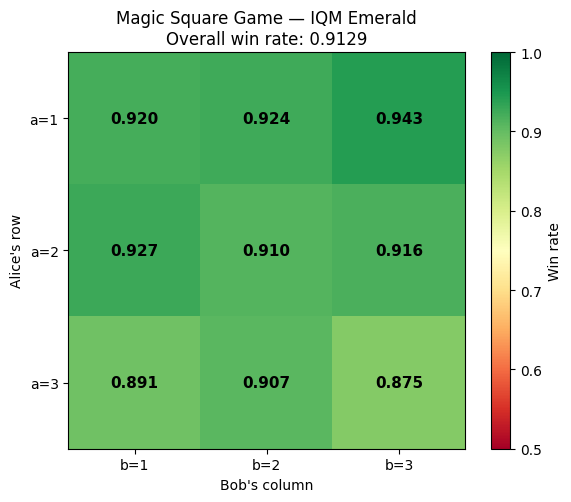


Classical bound:  0.8889
Measured average: 0.9129
✓ Beat classical by +0.0240 — quantum advantage demonstrated!


In [49]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(win_grid, cmap="RdYlGn", vmin=0.5, vmax=1.0)

ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(["b=1", "b=2", "b=3"])
ax.set_yticklabels(["a=1", "a=2", "a=3"])
ax.set_xlabel("Bob's column")
ax.set_ylabel("Alice's row")
ax.set_title(f"Magic Square Game — {label}\nOverall win rate: {overall:.4f}")

for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{win_grid[i,j]:.3f}", ha="center", va="center",
                color="black", fontsize=11, fontweight="bold")

fig.colorbar(im, ax=ax, label="Win rate")
ax.axhline(y=-0.5, color="black", linewidth=0)
plt.tight_layout()
plt.show()

print(f"\nClassical bound:  {8/9:.4f}")
print(f"Measured average: {overall:.4f}")
if overall > 8/9:
    print(f"✓ Beat classical by {overall - 8/9:+.4f} — quantum advantage demonstrated!")
else:
    print(f"✗ Below classical by {8/9 - overall:+.4f} — likely circuit too deep for current noise level")